## Задача классификации цвета автомобиля.

Датасет DVM: https://deepvisualmarketing.github.io/, использовать фронтальные виды.

Ход работы:
1. Написать своими руками классификатор любой на выбор: ResNet, InceptionV3,
DenseNet, MobileNet, ShuffleNet, и обучить его на датасете для предсказания цвета
автомобиля.
2. Также взять 2 классификатора, но предобученные на ImageNet или другом и дообучить
на предобработанном датасете DVM. Выяснить, чей классификатор лучше.
3. Оценить качество при помощи F1_macro, требуется получить F1_macro > 0.8.
4. Сравнить полученное качество у всех классификаторов между собой и сделать вывод.

## 1. Скачивание датасета

Скачиваем quality checked front-view images (730 MB) с Figshare.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from scripts.download_data import run as download_data

download_data(output_dir="data")

## 2. Подготовка данных

Парсинг структуры Brand/Model/Year/Colour и создание metadata.json.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

from scripts.prepare_metadata import run as prepare_metadata

prepare_metadata(
    data_root="data/dvm_front",
    output="data/metadata.json",
    min_samples=500,
)

Filtered 1263 samples from rare classes (< 500)
Saved metadata to data/metadata.json
Total samples: 60564, classes: 12


0

### 2.1 Статистика датасета

Всего изображений и разбиение по классам (из metadata.json).

Всего изображений: 60564
Классов: 12

Разбиение по классам:
----------------------------------------
Black   :  14317 ( 23.6%)
Grey    :   9474 ( 15.6%)
White   :   9395 ( 15.5%)
Blue    :   8483 ( 14.0%)
Silver  :   7770 ( 12.8%)
Red     :   6095 ( 10.1%)
Unlisted:   1516 (  2.5%)
Brown   :    911 (  1.5%)
Green   :    777 (  1.3%)
Yellow  :    667 (  1.1%)
Beige   :    600 (  1.0%)
Orange  :    559 (  0.9%)


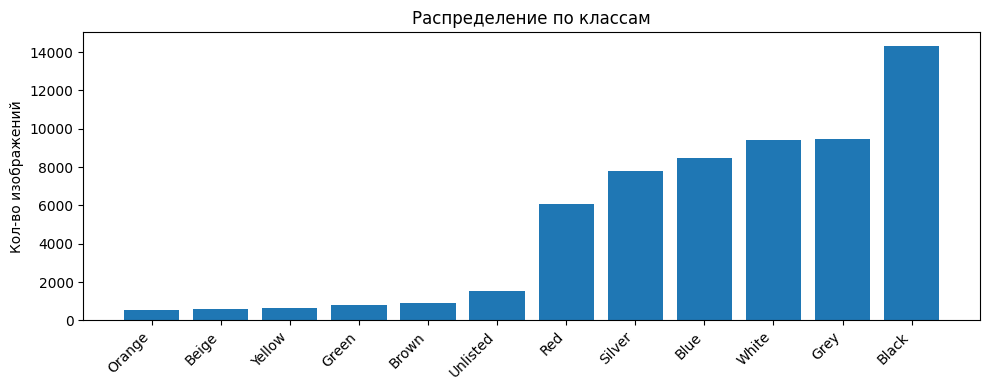

In [2]:
import json
from collections import Counter

with open("data/metadata.json") as f:
    meta = json.load(f)

counts = Counter(s["label"] for s in meta["samples"])
labels = meta["label_to_class"]
total = len(meta["samples"])

sorted_classes = sorted(((i, counts.get(i, 0)) for i in range(len(labels))), key=lambda x: x[1], reverse=True)

print(f"Всего изображений: {total}")
print(f"Классов: {meta['num_classes']}\n")
print("Разбиение по классам:")
print("-" * 40)
# Определяем максимальную ширину имени класса для ровной табуляции
max_name_len = max(len(labels[i]) for i, _ in sorted_classes)
for i, n in sorted_classes:
    name = labels[i]
    pct = 100 * n / total
    # Название: выровнено по левому краю, числа и скобки по правому
    print(f"{name:<{max_name_len}}: {n:6d} ({pct:5.1f}%)")


import matplotlib.pyplot as plt
sorted_classes.reverse()
plt.figure(figsize=(10, 4))
sorted_labels = [labels[i] for i, _ in sorted_classes]
sorted_counts = [n for _, n in sorted_classes]
plt.bar(sorted_labels, sorted_counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Кол-во изображений")
plt.title("Распределение по классам")
plt.tight_layout()
plt.show()

## 3. Обучение моделей

Обучаем ResNet-18 с нуля, ResNet50 и EfficientNet (предобученные на ImageNet). Логика — в `src/train.py`.

In [ ]:
import sys
sys.path.insert(0, str(Path.cwd()))

from src.train import run as train_model

for model_name in ["resnet18_scratch"]: # , "resnet50", "efficientnet"
    print(f"\n{'='*60}\nTraining {model_name}\n{'='*60}")
    train_model(
        model=model_name,
        metadata="data/metadata.json",
        output_dir="outputs",
        batch_size=64,
        epochs=10,
        gpus="0,1",
    )


Training resnet18_scratch


Resuming from epoch 40, best_val_f1=0.7881 (ещё 10 эпох)


Epoch 41 Loss: 0.1089 Val Acc: 0.8904 F1_macro: 0.7949
  -> Saved best (F1=0.7949)


Epoch 42 Loss: 0.1046 Val Acc: 0.8788 F1_macro: 0.7832


Epoch 43 Loss: 0.1003 Val Acc: 0.8785 F1_macro: 0.7743


Epoch 44 Loss: 0.0942 Val Acc: 0.8661 F1_macro: 0.7599


Epoch 45 Loss: 0.0961 Val Acc: 0.8740 F1_macro: 0.7743


Train:   0%|          | 0/757 [00:00<?, ?it/s]

## 4. отчёт

## Сравнение классификаторов

| Модель | Accuracy | F1_macro | Epochs |
|--------|----------|----------|--------|
| efficientnet | 0.9087 | 0.8237 | 10 |
| resnet50 | 0.8914 | 0.8021 | 10 |
| resnet18_scratch | 0.8915 | 0.8009 | 50 |

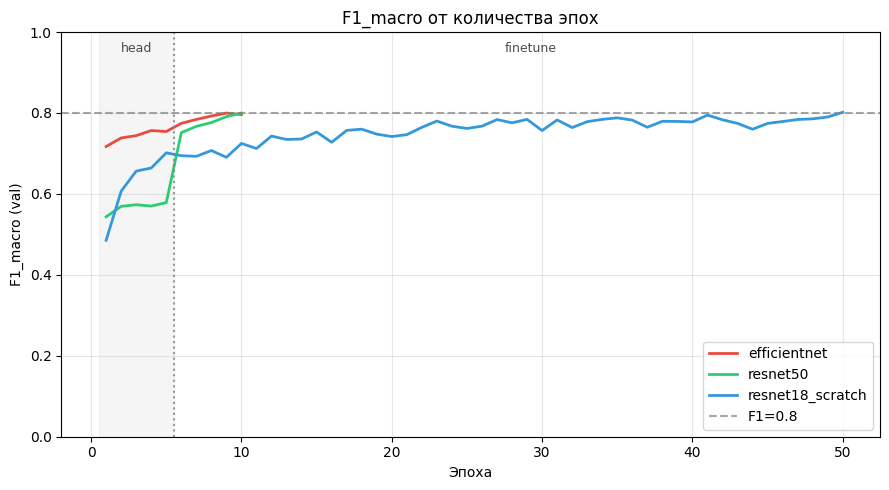

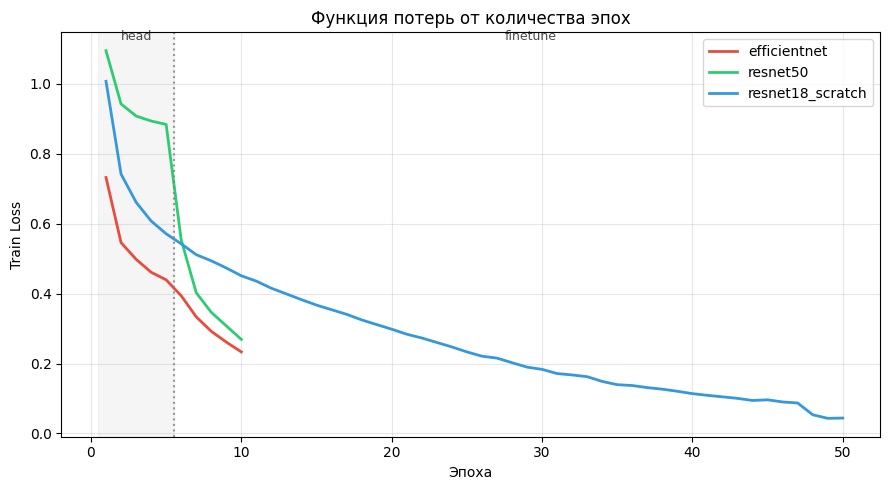

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

from IPython.display import display, Markdown
from src.report import load_results, format_report, plot_f1_vs_epochs, plot_loss_vs_epochs

results = load_results("outputs")
display(Markdown(format_report(results)))
plot_f1_vs_epochs(results)
plot_loss_vs_epochs(results)

### Вывод:
По результатам на тестовой выборке предобученные модели (ResNet50, EfficientNet) в среднем показывают более высокое качество, чем ResNet-18, обученный с нуля, за счёт переноса признаков с ImageNet. ResNet-18 с нуля сходится медленнее и требует больше эпох. F1_macro учитывает дисбаланс классов и отражает качество по каждому цвету; accuracy может завышать оценку при доминировании частых классов.